In [1]:
%matplotlib widget
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'
import warp as wp; wp.init()

import torch
# from compressibleSPH.gencase import *
from compressibleSPH.sample import generateInitialVariables, SamplingScheme
from compressibleSPH.sampling import  sampleParticles
# from waves.util import plotState, plotInitialState
# from simulation import runSimulation
from compressibleSPH.utils import getCurrentTimestamp
from argparse import ArgumentParser
from compressibleSPH.casefile import argparse_defaults_from_casefile, load_casefile

# from compressibleSPH.systemv3 import WaveSystemStatev3
from compressibleSPH.sample import smoothState
# from compressibleSPH.systemv3 import WaveSystemv3, f_wave_equation
from integrators.integration import *
from compressibleSPH.utils import *
from sphWarpCore import *
# from compressibleSPH.systemv3 import WaveSystemStatev3

from sphWarpCore.radiusSearch.verlet import *
from sphWarpCore.radius import AdjacencyList
from sphWarpCore.operations import *
from sphWarpCore.enumTypes import *

from sphWarpCore import *
# from waves.sampling import sampleParticles
# from compressibleSPH.systemv3 import sampleInitialWaveState
# from compressibleSPH.systemv3 import computeDt
from compressibleSPH.sampling import finalizeWaveSystemSetup
from compressibleSPH.shape_generation import populateSourceObstacleGridsStructured

from compressibleSPH.config import SimulationConfig, CompressibleSPHConfig
from compressibleSPH.caseUtils.sod import *
from compressibleSPH.util import *
from compressibleSPH.schemes import *
from sphWarpCore.diffusion.viscosity import DiffusionParameters

from diffSPH.enums import ViscositySwitch, KernelType
from torch.profiler import profile, record_function, ProfilerActivity
from tqdm.autonotebook import tqdm

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [ ]:
nx = 2**16
gamma = 5/3
leftState = sodInitialState(1, 1, 0)
rightState = sodInitialState(0.1795, 0.25, 0)
samplingRatio = 4
smoothIC = True
timeLimit = 0.15

L = 2
dim = 1
n_h = 4
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = torch.float32

config = SimulationConfig(
    domain = buildDomainDescription(L, dim, True, device, dtype),
    dim = dim,
    kernel = KernelFunctions.Wendland2,
    targetNeighbors = n_h_to_nH(n_h, dim),
    supportMode = SupportScheme.Gather,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta4,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = 1e-3,
    adaptiveDt = False,
    cflFactor=0.3,
)

diffusionParams = DiffusionParameters()
diffusionParams.c_s = 1
diffusionParams.C_l = 1
diffusionParams.C_q = 0
diffusionParams.Cu_l = 1
diffusionParams.Cu_q = 0
diffusionParams.K = 1.0
diffusionParams.thermalConductivity = 0.5
diffusionParams.viscosityTerm = 7
diffusionParams.thermalConducitiyTerm = 9
diffusionParams.scaleBeta = False
diffusionParams.monaghanSwitch = True
diffusionParams.correctXi = True

compressibleSPHConfig = CompressibleSPHConfig(
    gamma = gamma,
    rho0 = leftState.rho,
    diffusionParams = diffusionParams,
)
integrator = getIntegrator(config.integrationScheme)


In [ ]:
from sphWarpCore.kernels.wp_kernel import sphKernel_xi
targetCFL = 0.3
# The initial state contains density and pressure
# we can get the internal energies for each state via the gas EOS
u_left = leftState.p / ((gamma - 1) * leftState.rho)
u_right = rightState.p / ((gamma - 1) * rightState.rho)
# this then gives us the speed of sound for each state, which we can use to determine the initial timestep based on the CFL condition
c_s_left =  np.sqrt(u_left * gamma * (gamma - 1))
c_s_right =  np.sqrt(u_right * gamma * (gamma - 1))

# We cab then get the minimum support radius based on the initial sampling and use this to get the initial timestep
# The sampling is done such that with a sampling ratio of 1 th left and right states each have nx particles
# The sampling ratio then reduces the number of particles by that factor
# accordingly, the higher resolution is always the unmultiplied L/2 /nx
dx = L / (nx * 2)
h = volumeToSupportHelper(dx, config.targetNeighbors, config.dim)
xi = sphKernel_xi(config.kernel.value, config.dim)

dt_cfl_left = targetCFL * h / (c_s_left + h * xi)
dt_cfl_right = targetCFL * h / (c_s_right + h * xi)
initial_dt = np.min([dt_cfl_left, dt_cfl_right])
config.dt = initial_dt

print(f"Internal energy left: {u_left}, right: {u_right}")
print(f"Speed of sound left: {c_s_left}, right: {c_s_right}")
print(f"Initial support radius: {h}, xi: {xi}")
print(f"Initial dt based on CFL condition left: {dt_cfl_left}, right: {dt_cfl_right}")
print(f"Initial dt based on CFL condition: {initial_dt}")

In [3]:
compSystem = buildSod1D(
    nx,
    samplingRatio,
    leftState,
    rightState,
    gamma, config,
    smoothIC
)

Left particles: 8192, Right particles: 2048
Module sphWarpCore.radiusSearch.wp_compactHash e835d56 load on device 'cuda:0' took 8.82 ms  (cached)
Module sphWarpCore.operations_grid.wp_density_grid e6317f6 load on device 'cuda:0' took 5.80 ms  (cached)
Module sphWarpCore.operations.wp_density 896c489 load on device 'cuda:0' took 5.62 ms  (cached)
Module compressibleSPH.modules.adaptiveSupport.wp_omega 74a214d load on device 'cuda:0' took 8.81 ms  (cached)


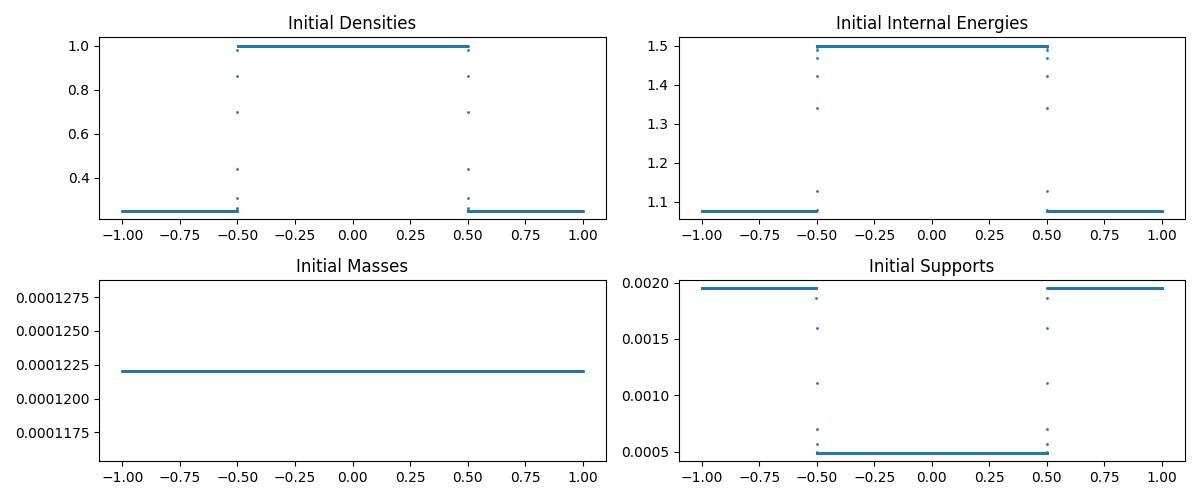

In [4]:
fig, axis = plt.subplots(2,2, figsize = (12, 5), squeeze = False)
plotToAxis1D(axis[0,0], compSystem.state.positions, compSystem.state.densities, title = 'Initial Densities')
plotToAxis1D(axis[1,0], compSystem.state.positions, compSystem.state.masses, title = 'Initial Masses')
plotToAxis1D(axis[0,1], compSystem.state.positions, compSystem.state.internalEnergies, title = 'Initial Internal Energies')
plotToAxis1D(axis[1,1], compSystem.state.positions, compSystem.state.supports, title = 'Initial Supports')
fig.tight_layout()

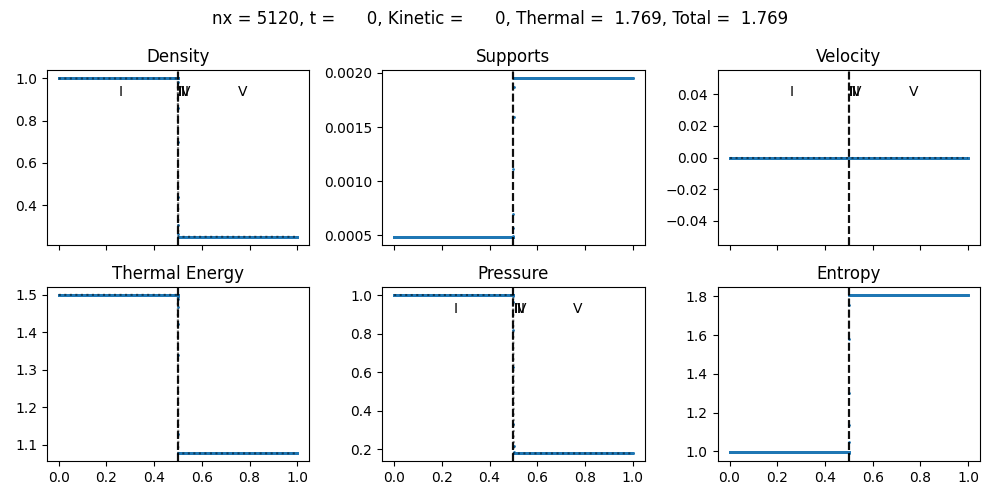

In [5]:
plotSod(compSystem.state, None, None, gamma, leftState, rightState, plotReference = True, plotLabels = True, scatter = True, t_ = compSystem.t)

In [6]:
from diffSPH.schemes.states.compressiblesph import CompressibleState as CompState
from diffSPH.operations import sph_op, SPHOperation
from diffSPH.schemes.states.wcsph import WeaklyCompressibleState
from diffSPH.schemes.gasDynamics import CompressibleState
from diffSPH.neighborhood import SparseNeighborhood, PrecomputedNeighborhood, SupportScheme, NeighborhoodInformation
from diffSPH.operations import DivergenceMode, GradientMode, Operation, LaplacianMode
from diffSPH.operations import KernelCorrectionScheme, SPHKernel
from typing import Union, Tuple, Dict
from diffSPH.neighborhood import evaluateNeighborhood
from diffSPH.enums import KernelType
from diffSPH.kernels import getSPHKernelv2

from diffSPH.simple import SupportScheme as SupportSchemeDiffSPH, ViscositySwitch
from diffSPH.operations import sph_op
from diffSPH.sphOperations.shared import compute_xij, getTerms
from diffSPH.modules.viscosity import compute_Pi
from diffSPH.modules.adaptiveSmoothingASPH import evaluateOptimalSupportOwen
from diffSPH.schemes.gasDynamics import CompressibleSystem, CompressibleUpdate, CompressibleState
from diffSPH.kernels import evalW, evalGradW, evalDerivativeW
import copy
from diffSPH.modules.velocityDiffusion import computeViscosity_Monaghan1997
from diffSPH.modules.energyDiffusion import computeMonaghan1997Dissipation
from diffSPH.modules.switches.CullenDehnen2010 import computeCullenTerms, computeCullenUpdate
from diffSPH.schemes.gasDynamics import CompressibleSystem, CompressibleUpdate, verbosePrint, checkTensor
from diffSPH.modules.viscositySwitch import computeViscositySwitch, updateViscositySwitch
from diffSPH.neighborhood import SupportScheme, evaluateNeighborhood
from diffSPH.regions import enforceDirichlet, enforceDirichletUpdate, applyForcing
from diffSPH.modules.momentum import computeMomentum, computeMomentumConsistent
import copy

currentState = copy.deepcopy(compSystem.state)
diffSPHState = CompState(
    positions = currentState.positions,
    velocities = currentState.velocities,
    densities = currentState.densities,
    supports = currentState.supports,
    internalEnergies = currentState.internalEnergies,
    totalEnergies = currentState.totalEnergies,
    entropies = currentState.entropies,
    soundspeeds= currentState.soundspeeds,
    masses = currentState.masses,
    kinds = currentState.kinds,
    materials = currentState.materials,
    UIDs = currentState.UIDs,
    pressures = currentState.pressures,
    omega = None,
)

diffSPHSystem = CompressibleSystem(
    systemState = diffSPHState,
    domain = config.domain,
    neighborhoodInfo=None,
    t = 0.0
)

wrappedKernel = getSPHKernelv2(KernelType.Wendland2)
verletScale = 2 ** (1/config.dim)
verletScale = 1


In [7]:
from diffSPH.enums import *

diffSPHDiffusionConfig = {    
    'diffusion':{
        'C_l': 1,
        'C_q': 0,
        'Cu_l': 1,
        'Cu_q': 0,
        'monaghanSwitch': True,
        'viscosityTerm': 'Monaghan',
        'correctXi': True,
        
        'viscosityFormulation': 'Price2012_98',
        'thermalConductivityFormulation': 'Price2008',
        'signalTerm': 'Price2019',
        'K': 1.0,
        
        'thermalConductivity' : 0.5,
    },
    'diffusionSwitch':{
        'scheme': ViscositySwitch.NoneSwitch,
        'limitXi': False,
    },
    'domain': config.domain,
    'kernel': KernelType.Wendland2,
    'verbose': True,
    'targetNeighbors': config.targetNeighbors,
    'support': {
        'scheme': AdaptiveSupportScheme.MonaghanScheme
    },
    'neighborhood': {
        'verletScale': verletScale,
    },
    'regions' : {},
    'fluid':{
        'gamma': gamma,
    },
    'correctiveOmega': True
}

In [8]:
from diffSPH.schemes.monaghanPrice import MonaghanScheme

result = MonaghanScheme(
    diffSPHSystem,
    config.dt, 
    diffSPHDiffusionConfig,
    verbose = False
)

In [9]:
from diffSPH.integration import *
diffSPHIntegrator = getIntegrator(IntegrationSchemeType.rungeKutta4)



In [12]:
simulationState = diffSPHSystem.initializeNewState()
_, currentState, updates = diffSPHIntegrator.function(simulationState, config.dt, MonaghanScheme, diffSPHDiffusionConfig, priorStep = None, verbose = False)


In [13]:
with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], record_shapes=True) as prof:
    _, currentState, updates = diffSPHIntegrator.function(simulationState, config.dt, MonaghanScheme, diffSPHDiffusionConfig, priorStep = None, verbose = False)

print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=10))
prof.export_chrome_trace("diffSPH_trace.json")

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                      [CompSPH] - 01 - Optimize Support         0.00%       0.000us         0.00%       0.000us       0.000us        1.111s      1386.35%        1.111s     277.668ms             4  
                                  [Neighborhood] verlet         0.00%       0.000us         0.00%       0.000us       0.000us     321.050ms       400.74%     321.050ms       4.721ms            68  
         

In [ ]:
for i in tqdm(range(1024)):
    simulationState, currentState, updates = diffSPHIntegrator.function(simulationState, config.dt, MonaghanScheme, diffSPHDiffusionConfig, priorStep = None, verbose = False)

  0%|          | 0/256 [00:00<?, ?it/s]

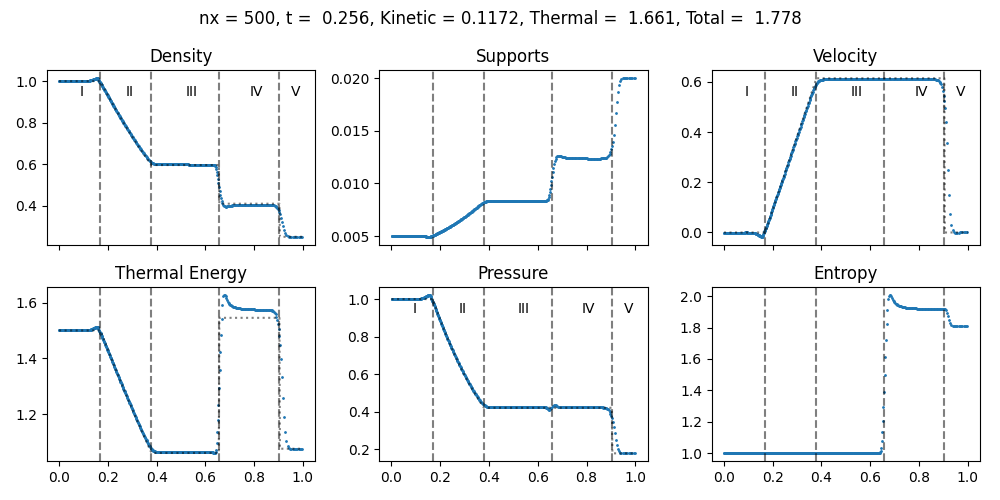

In [13]:
plotSod(simulationState.systemState, None, None, gamma, leftState, rightState, plotReference = True, plotLabels = True, scatter = True, t_ = simulationState.t)